In [1]:
from pathlib import Path
from utility import get_profiler_result, search_profiler_file
from perf_estimator.estimator import Estimator, TrainerEstimator
from perf_estimator.dataset import image_dataset
from experiments_llm.plot import display_memory_lifecycle


In [2]:
model = "VGG11"
batch_size = 10
optimizer = "Adam"
root_dir = Path("/home/glaswigian/Documents/200-ResearchData/101-xMem-LLM")
paper_data_dir = root_dir / "003-Paper-profiling" / f"recurrence-{model}-{optimizer}-{batch_size}-1"
tainer_data_dir = root_dir / "001-CPU-profiling" / f"{model}-{batch_size}-{optimizer}"

In [3]:
paper_data_file = search_profiler_file(paper_data_dir)[-2]
paper_result = Estimator(
    dataloader=image_dataset(batch=int(batch_size)),
    profiler_file=paper_data_file,
    max_gpu_memory_in_gb=8,
)
paper_result, _ = paper_result.estimate()

In [4]:
tainer_data_file = search_profiler_file(tainer_data_dir)[-1]
tainer_result = TrainerEstimator(
    dataloader=image_dataset(batch=int(batch_size)),
    profiler_file=tainer_data_file,
    max_gpu_memory_in_gb=8,
)
tainer_result, _ = tainer_result.estimate()

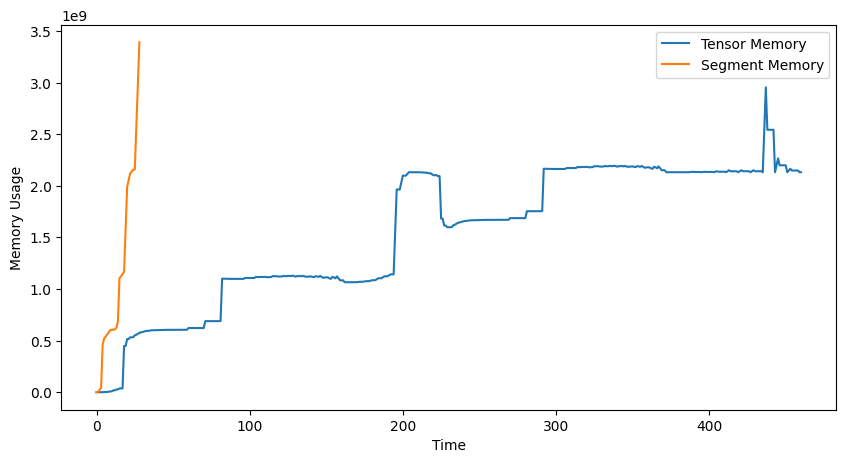

In [5]:
paper_result.plot_memory_change()

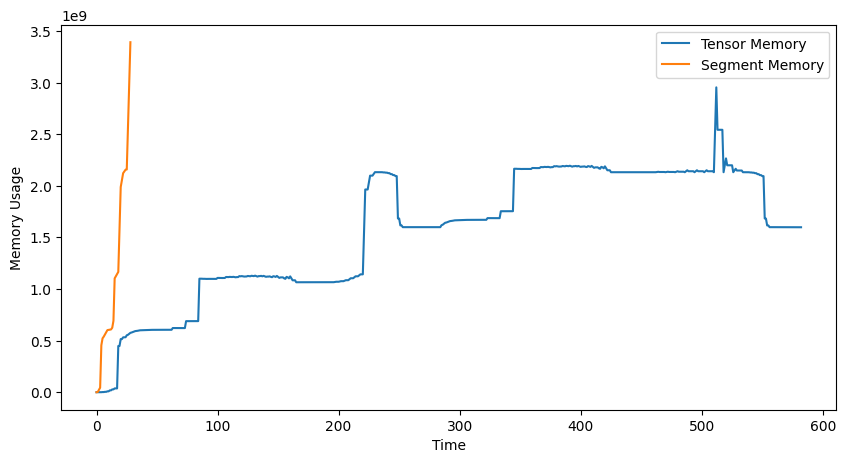

In [6]:
tainer_result.plot_memory_change()

In [7]:
print(f"Paper max seg: {max(paper_result._trace.max_segment_changes)}")
print(f"Paper max seg: {max(tainer_result._trace.max_segment_changes)}")


Paper max seg: 3391094784
Paper max seg: 3391094784


In [10]:
root_dir = Path("/home/mechrevo/Documents/101-ResearchData/002-xMem-LLm/003-Analysis Profiling Results for LLMs")
neo_dir = root_dir / "EleutherAI-gpt-neo-125M-cpu"
neo_dir = root_dir / "facebook-opt-125m-cpu"
neo_data_file = search_profiler_file(neo_dir)[-1]

In [11]:
batch_size=10
tainer_est = TrainerEstimator(
    dataloader=image_dataset(batch=int(batch_size)),
    profiler_file=neo_data_file,
    max_gpu_memory_in_gb=8,
)
tainer_result, _ = tainer_est.estimate()

Duplicate layer name found: OPTDecoderLayer_11. Renaming to OPTDecoderLayer_11_29
Duplicate layer name found: LayerNorm_22. Renaming to LayerNorm_22_72
Duplicate layer name found: OPTSdpaAttention_11. Renaming to OPTSdpaAttention_11_91
Duplicate layer name found: Linear_66. Renaming to Linear_66_a8
Duplicate layer name found: Linear_67. Renaming to Linear_67_8c
Duplicate layer name found: Linear_68. Renaming to Linear_68_43
Duplicate layer name found: Linear_69. Renaming to Linear_69_3a
Duplicate layer name found: LayerNorm_23. Renaming to LayerNorm_23_32
Duplicate layer name found: Linear_70. Renaming to Linear_70_1e
Duplicate layer name found: ReLU_11. Renaming to ReLU_11_6c
Duplicate layer name found: Linear_71. Renaming to Linear_71_05
Duplicate layer name found: OPTDecoderLayer_10. Renaming to OPTDecoderLayer_10_57
Duplicate layer name found: LayerNorm_20. Renaming to LayerNorm_20_2c
Duplicate layer name found: OPTSdpaAttention_10. Renaming to OPTSdpaAttention_10_3e
Duplicate laye

In [12]:
layer_memory_list = tainer_est.profiler.get_iteration(1).layer_summary()

In [13]:
first_layer = layer_memory_list[0]
type(first_layer)

dict

In [16]:
memory_blocks = []
for layer in layer_memory_list[6:27]:
    layers = layer["forward_memory"]
    layers += layer["backward_memory"]
    for memory_block in layers:
        memory_info = {
            "alloc": memory_block.alloc_time,
            "free": memory_block.free_time,
            "size": memory_block.bytes,
            "name": layer["name"],
            "address": memory_block.address,
        }
        memory_blocks.append(memory_info)


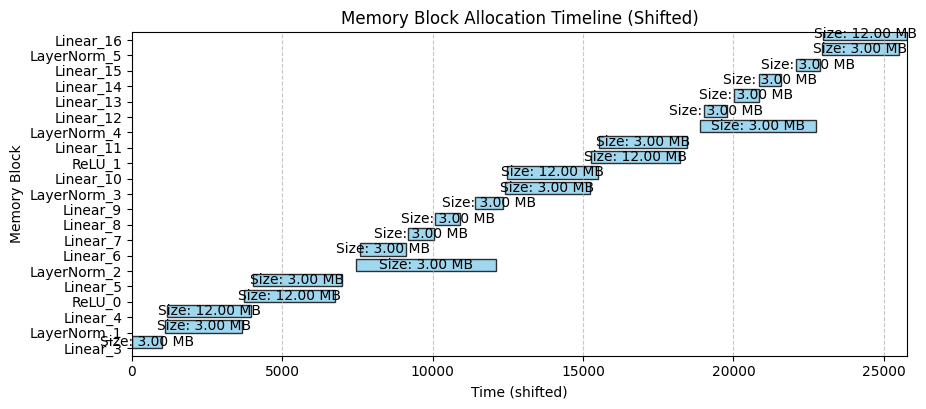

In [17]:
display_memory_lifecycle(memory_blocks)